# importar librerias


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats
import seaborn as sns


### Ejercicio 1. Publicidad y ventas
##### El archivo ventas.txt contiene información del departamento de ventas de una empresa que desea estudiar la influencia de la inversión publicitaria realizada a través de distintos medios sobre las ventas de un producto. Se dispone de información correspondiente a 200 regiones. Para cada región se registra el ingreso por ventas, expresado en millones, y el presupuesto destinado a publicidad en televisión, radio y periódicos, también expresado en millones.


a) [4 puntos] Realice un EDA en R y en Python que incluya, al menos:
- dimensiones y estructura de la base;
- identificación de datos faltantes;
- medidas descriptivas de las variables;
- matriz de correlaciones;
- gráficos de dispersión entre ventas y cada predictor;
- comentarios breves sobre patrones, posibles asociaciones y observaciones atípicas

In [ ]:
data1 = pd.read_csv('ventas.txt', sep='\t') #leemos archivo de texto separado por tabulaciones
data1.head() #mostramos el archivo

,tv,radio,periodico,ventas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
data1.info() #mostramos la informacion de la data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tv         180 non-null    float64
 1   radio      180 non-null    float64
 2   periodico  180 non-null    float64
 3   ventas     180 non-null    float64
dtypes: float64(4)
memory usage: 5.8 KB


In [ ]:
data1.isnull().sum() #mostramos la cantidad de datos faltantes

,0
tv,0
radio,0
periodico,0
ventas,0


In [ ]:
data1.describe()

,tv,radio,periodico,ventas
count,180.000000,180.000000,180.000000,180.000000
mean,144.937778,22.523333,30.715556,13.788889
std,84.615857,14.549235,22.189889,5.110488
min,0.700000,0.000000,0.300000,1.600000
25%,72.700000,9.300000,12.550000,10.300000
50%,145.100000,22.000000,25.600000,12.750000
75%,217.025000,35.450000,45.125000,17.225000
max,296.400000,49.400000,114.000000,27.000000


matriz de correlacion

In [ ]:
correlaciones =data1.corr()
print(correlaciones.round(3))

              tv  radio  periodico  ventas
tv         1.000  0.056      0.112   0.792
radio      0.056  1.000      0.384   0.560
periodico  0.112  0.384      1.000   0.283
ventas     0.792  0.560      0.283   1.000


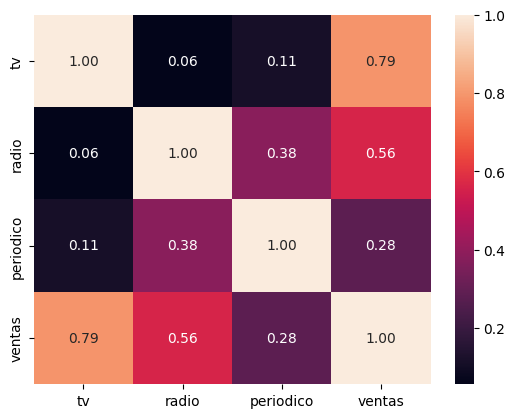

In [ ]:

sns.heatmap(data1.corr(),annot=True,fmt='0.2f') #mapa de calor
plt.show()

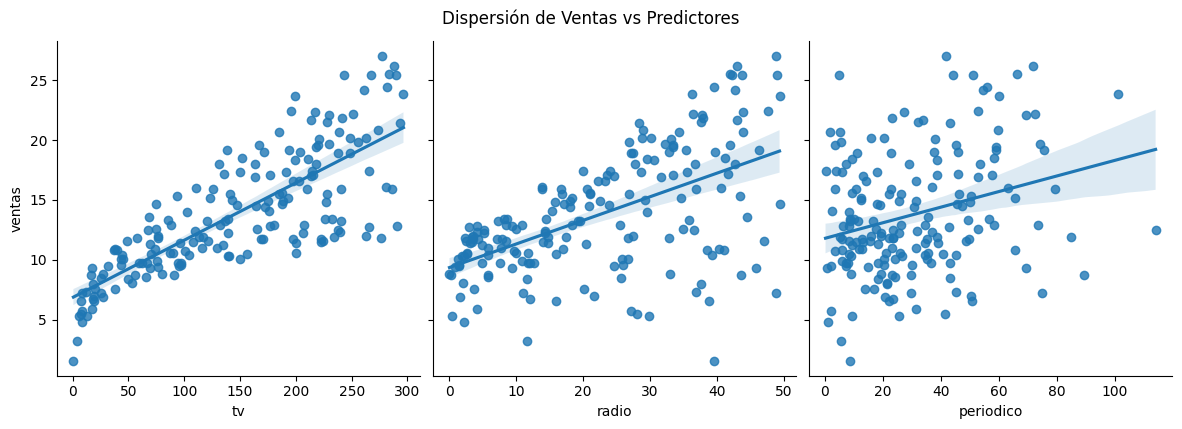

In [ ]:
sns.pairplot(data1, x_vars=['tv', 'radio', 'periodico'], y_vars='ventas', height=4, aspect=1, kind='reg')
plt.suptitle('Dispersión de Ventas vs Predictores', y=1.05)
plt.show()

b) [5 puntos] Ajuste, en R y Python, el modelo de regresión lineal múltiple

Ventas_i = β0 + β1T Vi + β2Radioi + β3P eriodicoi + εi
,
donde

εi
iid∼ N(0, σ2
).

Presente e interprete:
- los coeficientes estimados;
- el signo de cada coeficiente;
- el estadístico del contraste F global;
- el p-valor asociado al contraste F.
- Compare los resultados obtenidos en ambos lenguajes.

In [ ]:
# Ajustar el modelo de regresión lineal múltiple
# Ventas_i = β0 + β1TVi + β2Radioi + β3Periodicoi + εi
model = smf.ols('ventas ~ tv + radio + periodico', data=data1).fit()

# Presentar los resultados del modelo de regresión lineal
print("\n--- Resultados del Modelo de Regresión Lineal en Python ---")
print(model.summary())


--- Resultados del Modelo de Regresión Lineal en Python ---
                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     494.3
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.84e-85
Time:                        06:22:51   Log-Likelihood:                -346.63
No. Observations:                 180   AIC:                             701.3
Df Residuals:                     176   BIC:                             714.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [ ]:

print(model.params)



Intercept    3.020434
tv           0.046085
radio        0.181883
periodico   -0.000246
dtype: float64


In [ ]:
f_statistic = model.fvalue
p_value_f_statistic = model.f_pvalue
print("Estadístico F:", f_statistic)
print("p-valor del contraste F:", p_value_f_statistic)



Estadístico F: 494.2940694243362
p-valor del contraste F: 1.835783140686822e-85


c) [4 puntos] Obtenga, en R y Python, un intervalo de confianza del 95 % para el valor medio
esperado de las ventas cuando la inversión publicitaria es
T V = 147.05, Radio = 23.3, P eriodico = 31.

- Interprete el intervalo obtenido en el contexto del problema y verifique que ambos lenguajes
entreguen resultados equivalentes salvo diferencias de redondeo.


In [ ]:
# Definir los valores de las variables para los cuales se quiere el intervalo de confianza
new_data = pd.DataFrame({'tv': [147.05], 'radio': [23.3], 'periodico': [31.0]})

# Obtener las predicciones y el intervalo de confianza para la media esperada (mean_ci)
predictions = model.get_prediction(new_data)
summary_frame = predictions.summary_frame(alpha=0.05) # alpha=0.05 para un 95% de confianza

# Extraer el intervalo de confianza para la media
mean_ci_lower = summary_frame['mean_ci_lower'][0]
mean_ci_upper = summary_frame['mean_ci_upper'][0]

print(f"Valor predicho de las ventas: {summary_frame['mean'][0]:.2f}")
print(f"Intervalo de confianza del 95% para el valor medio esperado de las ventas: ({mean_ci_lower:.2f}, {mean_ci_upper:.2f})")


Valor predicho de las ventas: 14.03
Intervalo de confianza del 95% para el valor medio esperado de las ventas: (13.78, 14.27)


d) [4 puntos] Para una nueva sucursal, el gerente planea invertir
T V = 160, Radio = 26.7, P eriodico = 35.1.
- Obtenga, en R y Python,
V entas ˆ︂
y un intervalo de predicción del 95 % para el volumen de ventas de dicha sucursal.

In [ ]:
# Definir los valores de las variables para la nueva sucursal
new_branch_data = pd.DataFrame({'tv': [160.0], 'radio': [26.7], 'periodico': [35.1]})

# Obtener las predicciones y el intervalo de predicción para una nueva observación (obs_ci)
predictions_new_branch = model.get_prediction(new_branch_data)
summary_frame_new_branch = predictions_new_branch.summary_frame(alpha=0.05) # alpha=0.05 para un 95% de confianza

# Extraer el valor predicho y el intervalo de predicción
predicted_sales = summary_frame_new_branch['mean'][0]
obs_ci_lower = summary_frame_new_branch['obs_ci_lower'][0]
obs_ci_upper = summary_frame_new_branch['obs_ci_upper'][0]

print(f"Ventas predichas para la nueva sucursal (Ventas^): {predicted_sales:.2f}")
print(f"Intervalo de predicción del 95% para el volumen de ventas: ({obs_ci_lower:.2f}, {obs_ci_upper:.2f})")


Ventas predichas para la nueva sucursal (Ventas^): 15.24
Intervalo de predicción del 95% para el volumen de ventas: (11.92, 18.56)



e) [3 puntos] Explique la diferencia conceptual entre los resultados obtenidos en los apartados
anteriores. En su respuesta, distinga entre

E(Y | X = x0)
y
Ynuevo | X = x0.

- Explique además por qué, en general, un intervalo de predicción para una nueva observación es
más amplio que un intervalo de confianza para la respuesta media.

###Ejercicio 2. Biomasa y características del suelo
El archivo datos.txt contiene información de un estudio cuyo propósito es identificar características
del suelo que pueden influir sobre la biomasa Y de una especie de pasto.
Se registraron las siguientes variables:

X1 = salinidad ( %), X2 = pH,
X3 = potasio (ppm), X4 = sodio (ppm), X5 = zinc (ppm).

El objetivo es estudiar por qué ajustar varias regresiones lineales simples de manera independiente no es
equivalente a ajustar directamente un modelo de regresión lineal múltiple.

 a. Realice un EDA en R y en Python que incluya:

* estructura y dimensiones de la base;
* revisión de datos faltantes;
* estadísticos descriptivos;
* matriz de correlaciones;
* gráficos pertinentes entre Y , X2 y X3;
* interpretación breve de la relación observada entre estas variables.

In [ ]:
data2 = pd.read_csv('datos.txt', sep='\t') #leemos archivo de texto separado por tabulaciones
data2.head() #mostramos el archivo

,biomasa,salinidad,pH,K,Na,Zn
0,516,35,4.75,1299.19,28170.4,13.9852
1,1052,32,4.20,1154.27,26455.0,15.3276
2,868,30,4.40,1045.15,25072.9,17.3128
3,1008,33,5.55,521.62,31664.2,22.3312
4,544,36,4.25,1346.35,20877.3,17.8225


In [ ]:
data2.info() #mostramos la informacion de la data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biomasa    40 non-null     int64  
 1   salinidad  40 non-null     int64  
 2   pH         40 non-null     float64
 3   K          40 non-null     float64
 4   Na         40 non-null     float64
 5   Zn         40 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 2.0 KB


In [ ]:
data2.isnull().sum() #mostramos la cantidad de datos faltantes

,0
biomasa,0
salinidad,0
pH,0
K,0
Na,0
Zn,0


In [ ]:
data2.describe()

,biomasa,salinidad,pH,K,Na,Zn
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,1060.900000,30.300000,4.642500,777.627250,15934.402500,17.419288
std,673.070873,3.824348,1.283802,282.104122,6397.248729,8.287186
min,236.000000,24.000000,3.200000,350.730000,7886.500000,0.210500
25%,473.000000,27.000000,3.487500,527.980000,11106.700000,13.909550
50%,994.000000,30.000000,4.425000,747.010000,14663.950000,19.620550
75%,1630.000000,33.250000,5.362500,951.987500,18131.500000,22.417350
max,2436.000000,38.000000,7.450000,1346.350000,31664.200000,30.558900


In [ ]:
correlaciones =data2.corr()
print(correlaciones.round(3))

           biomasa  salinidad     pH      K     Na     Zn
biomasa      1.000     -0.113  0.788 -0.207 -0.266 -0.628
salinidad   -0.113      1.000 -0.079 -0.099  0.118 -0.419
pH           0.788     -0.079  1.000 -0.055 -0.100 -0.703
K           -0.207     -0.099 -0.055  1.000  0.746  0.179
Na          -0.266      0.118 -0.100  0.746  1.000  0.195
Zn          -0.628     -0.419 -0.703  0.179  0.195  1.000


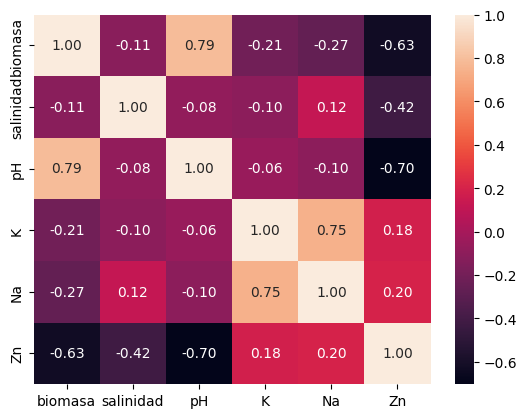

In [ ]:
sns.heatmap(data2.corr(),annot=True,fmt='0.2f') #mapa de calor
plt.show()

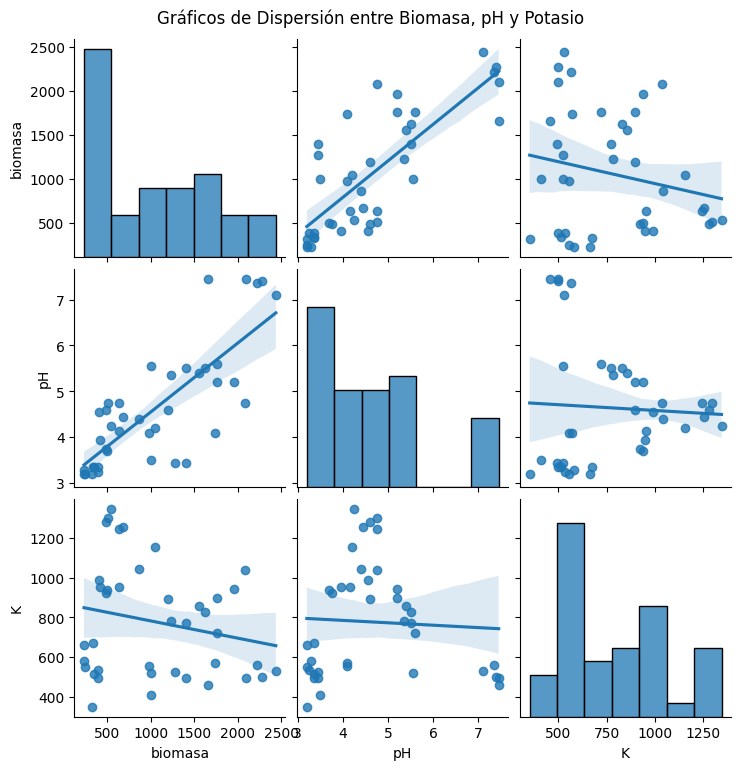

In [ ]:
# Crear un pairplot para Y (biomasa), X2 (pH) y X3 (K)
sns.pairplot(data2, vars=['biomasa', 'pH', 'K'], kind='reg')
plt.suptitle('Gráficos de Dispersión entre Biomasa, pH y Potasio', y=1.02) # Título general
plt.show()


b. Ajuste, en R y Python, el modelo de regresión lineal simple
* Y = β0 + β2X2 + ε.
Presente e interprete el coeficiente estimado asociado a X2.

In [ ]:

# Ajustar el modelo de regresión lineal simple: Y = β0 + β2X2 + ε
# Donde Y es 'biomasa' y X2 es 'pH'
model_simple = smf.ols('biomasa ~ pH', data=data2).fit()

print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                biomasa   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     62.30
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.58e-09
Time:                        06:23:09   Log-Likelihood:                -297.31
No. Observations:                  40   AIC:                             598.6
Df Residuals:                      38   BIC:                             602.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -857.3452    251.934     -3.403      0.0

In [ ]:
# Obtener el coeficiente estimado para pH (X2)
coeff_pH = model_simple.params['pH']
p_value_pH = model_simple.pvalues['pH']
print(f"Coeficiente estimado para pH: {coeff_pH}")
print(f"p-valor para pH: {p_value_pH}")

Coeficiente estimado para pH: 413.19227882120947
p-valor para pH: 1.5762683879593955e-09


c. Para estudiar el efecto de incorporar X3 controlando por X2, realice en R y Python
lo siguiente:

*   Ajuste la regresión
Y ∼ X2
y obtenga sus residuos, denotados por
eY .
*   Ajuste la regresión
X3 ∼ X2
y obtenga sus residuos, denotados por
eX3
.
* Construya un gráfico de
eY versus eX3
.
* . Explique qué representa cada conjunto de residuos en el contexto de este problema.




In [ ]:
model_Y_on_X2 = smf.ols('biomasa ~ pH', data=data2).fit()
eY = model_Y_on_X2.resid
print("Residuos de Y ~ X2 (eY):")
print(eY.head())

Residuos de Y ~ X2 (eY):
0   -589.318170
1    173.937583
2    -92.700872
3   -427.871993
4   -354.722031
dtype: float64


In [ ]:
model_X3_on_X2 = smf.ols('K ~ pH', data=data2).fit()
eX3 = model_X3_on_X2.resid
print("Residuos de X3 ~ X2 (eX3):")
print(eX3.head())

Residuos de X3 ~ X2 (eX3):
0    522.862043
1    371.294499
2    264.591788
3   -245.038803
4    563.978821
dtype: float64


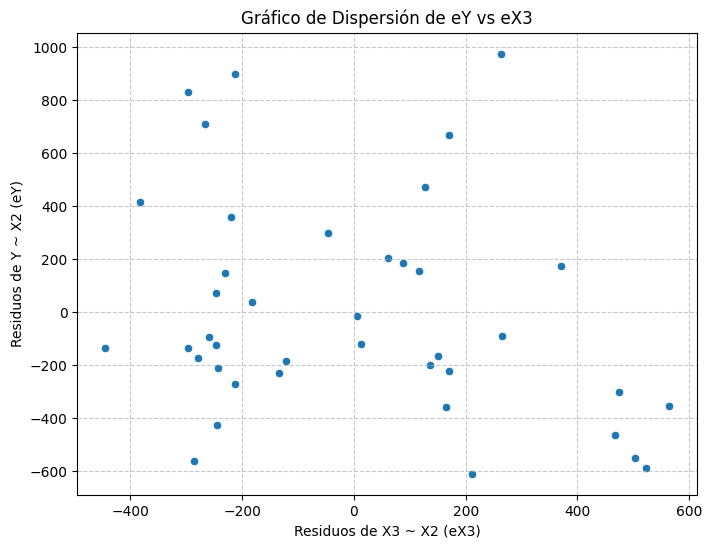

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=eX3, y=eY)
plt.title('Gráfico de Dispersión de eY vs eX3')
plt.xlabel('Residuos de X3 ~ X2 (eX3)')
plt.ylabel('Residuos de Y ~ X2 (eY)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

d.Ajuste, en R y Python, el modelo
eY = α + γeX3 + u
y registre el valor de la pendiente estimada
γ.


In [ ]:
model_eY_on_eX3 = smf.ols('eY ~ eX3', data=pd.DataFrame({'eY': eY, 'eX3': eX3})).fit()
gamma_hat = model_eY_on_eX3.params['eX3']
print(f"El valor de la pendiente estimada γ es: {gamma_hat:.4f}")

NameError: name 'smf' is not defined

e. Ajuste, en R y Python, el modelo de regresión múltiple
Y = β0 + β2X2 + β3X3 + ε.
Compare numéricamente
ˆ︁β3
con
γˆ︁
y verifique la equivalencia numérica entre ambos procedimientos y entre ambos lenguajes.

In [ ]:
# Ajustar el modelo de regresión múltiple: Y = β0 + β2X2 + β3X3 + ε
model_multiple = smf.ols('biomasa ~ pH + K', data=data2).fit()

# Obtener el coeficiente estimado para X3 (K), que es β3_hat
beta3_hat = model_multiple.params['K']

print("--- Modelo de Regresión Múltiple (biomasa ~ pH + K) ---")
print(model_multiple.summary())
print(f"\nEl valor de la pendiente estimada β3 (para K) es: {beta3_hat:.4f}")
print(f"El valor de la pendiente estimada γ es: {gamma_hat:.4f}")

# Comparar numéricamente β3_hat con γ_hat
if np.isclose(beta3_hat, gamma_hat):
    print("\nNumerically, β3_hat and γ_hat are equivalent, which verifies the equivalence between both procedures.")
else:
    print("\nNumerically, β3_hat and γ_hat are not equivalent.")
print(f"Diferencia absoluta: {abs(beta3_hat - gamma_hat):.6f}")

--- Modelo de Regresión Múltiple (biomasa ~ pH + K) ---
                            OLS Regression Results                            
Dep. Variable:                biomasa   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     34.07
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           4.07e-09
Time:                        06:23:09   Log-Likelihood:                -295.84
No. Observations:                  40   AIC:                             597.7
Df Residuals:                      37   BIC:                             602.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

f.Explique por qué el coeficiente de X3 obtenido en la regresión múltiple no corresponde,
en general, al coeficiente que se obtendría ajustando solamente
Y ∼ X3.
Relacione su explicación con la interpretación de
β3
como efecto parcial de X3 sobre Y , manteniendo constante X2.


#####Ejercicio 3. Selección de variables y esperanza de vida
Un estudio desea construir un modelo que permita predecir la esperanza de vida media de los habitantes
de los 50 estados de Estados Unidos en función de distintas variables explicativas.
El archivo esperanza.txt contiene información sobre las siguientes variables:

__Variable Descripción__
* habitantes: Número de habitantes.
* analfabetismo: Porcentaje de la población con analfabetismo.
* ingresos :Renta per cápita, expresada en dólares.
* asesinatos: Tasa de homicidios por cada 100 000 habitantes.
* universitarios: Porcentaje de graduados universitarios.
* heladas: Número promedio de días con temperatura mínima bajo el umbral considerado.
* area :Superficie del estado, medida en millas cuadradas.

Considere como variable respuesta la esperanza de vida media y utilice un nivel de significancia de
α = 0.01
en todos los procedimientos de selección

a.Realice un EDA en R y en Python que incluya:
* estructura y dimensiones de los datos;
* revisión de valores faltantes;
* medidas descriptivas;
* matriz de correlaciones;
* gráficos de dispersión entre esperanza de vida y cada predictor;
* identificación de posibles predictores asociados con la respuesta;
* comentario sobre posibles relaciones entre los propios predictores.

In [ ]:
data3 = pd.read_csv('esperanza.txt', sep='\t') #leemos archivo de texto separado por tabulaciones
data3.head() #mostramos el archivo

,habitantes,ingresos,analfabetismo,esp_vida,asesinatos,universitarios,heladas,area
0,25715,3804,2.1,69.05,15.1,41.3,66,50708
1,24314,4710,1.8,70.55,7.8,58.1,63,113417
2,24213,3558,1.9,70.66,10.1,39.9,114,51945
3,43302,5294,1.1,71.71,10.3,62.6,70,156361
4,24646,5064,0.7,72.06,6.8,63.9,217,103766


In [ ]:
data3.info() #mostramos la informacion de la data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   habitantes      45 non-null     int64  
 1   ingresos        45 non-null     int64  
 2   analfabetismo   45 non-null     float64
 3   esp_vida        45 non-null     float64
 4   asesinatos      45 non-null     float64
 5   universitarios  45 non-null     float64
 6   heladas         45 non-null     int64  
 7   area            45 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 2.9 KB


In [ ]:
data3.isnull().sum() #mostramos la cantidad de datos faltantes

,0
habitantes,0
ingresos,0
analfabetismo,0
esp_vida,0
asesinatos,0
universitarios,0
heladas,0
area,0


In [ ]:
data3.describe()

,habitantes,ingresos,analfabetismo,esp_vida,asesinatos,universitarios,heladas,area
count,45.00000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,26369.20000,4551.044444,1.166667,71.005778,7.006667,52.917778,172.666667,60524.822222
std,4520.21834,551.310998,0.625954,1.347719,3.701990,7.844752,58.651126,48328.742105
min,22525.00000,3278.000000,0.500000,67.960000,1.400000,37.800000,56.000000,1049.000000
25%,23274.00000,4163.000000,0.600000,70.320000,4.200000,48.800000,126.000000,30920.000000
50%,24955.00000,4648.000000,0.900000,70.880000,6.400000,53.300000,181.000000,54090.000000
75%,27040.00000,4935.000000,1.600000,72.060000,10.300000,59.000000,211.000000,79289.000000
max,43302.00000,5528.000000,2.800000,73.600000,15.100000,67.300000,268.000000,262134.000000


In [ ]:
correlaciones =data3.corr()
print(correlaciones.round(3))

                habitantes  ingresos  analfabetismo  esp_vida  asesinatos  \
habitantes           1.000     0.300          0.119    -0.101       0.388   
ingresos             0.300     1.000         -0.509     0.570      -0.415   
analfabetismo        0.119    -0.509          1.000    -0.644       0.758   
esp_vida            -0.101     0.570         -0.644     1.000      -0.761   
asesinatos           0.388    -0.415          0.758    -0.761       1.000   
universitarios      -0.045     0.582         -0.684     0.733      -0.599   
heladas             -0.307     0.088         -0.654     0.334      -0.647   
area                 0.272    -0.047          0.058     0.086       0.186   

                universitarios  heladas   area  
habitantes              -0.045   -0.307  0.272  
ingresos                 0.582    0.088 -0.047  
analfabetismo           -0.684   -0.654  0.058  
esp_vida                 0.733    0.334  0.086  
asesinatos              -0.599   -0.647  0.186  
universitari

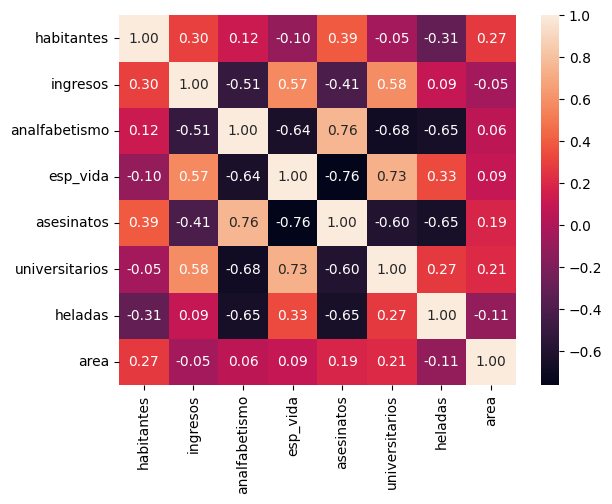

In [ ]:
sns.heatmap(data3.corr(),annot=True,fmt='0.2f') #mapa de calor
plt.show()

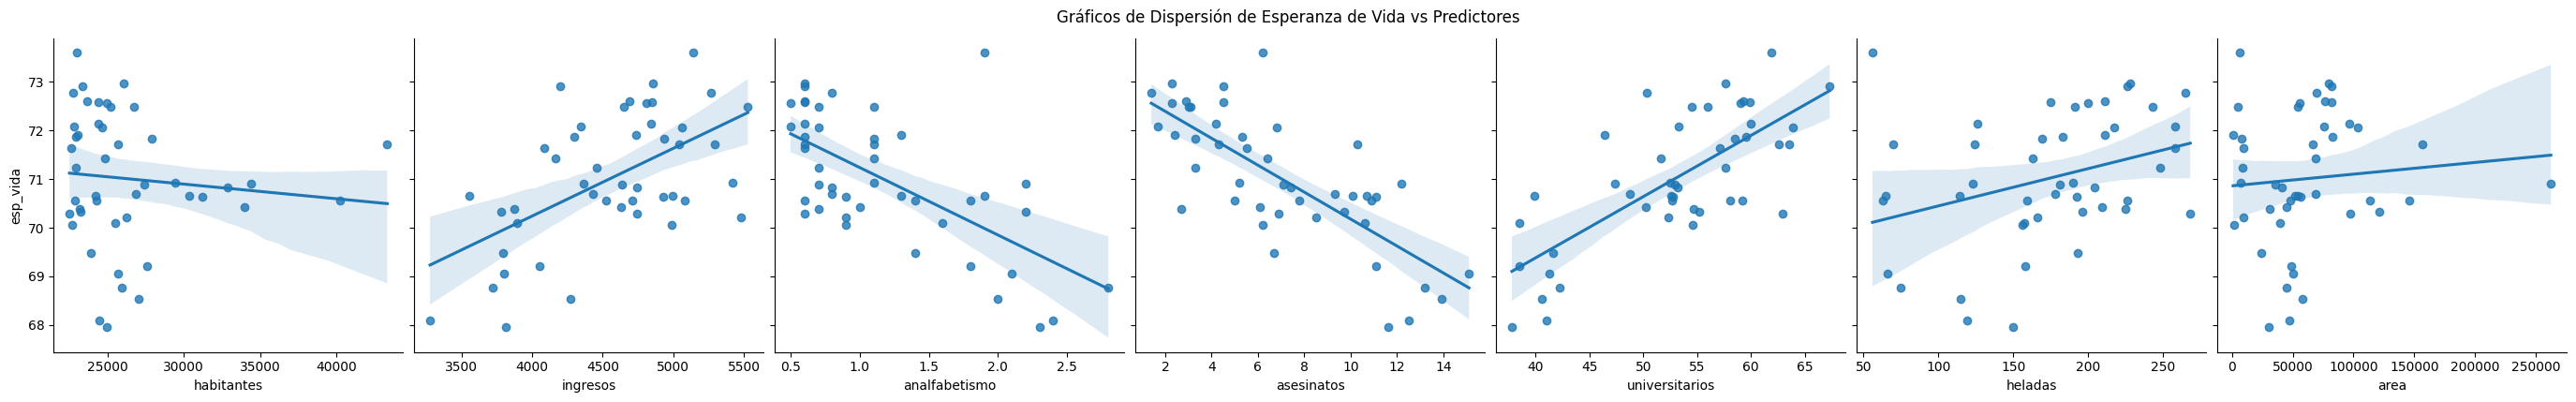

In [ ]:
predictor_vars = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
sns.pairplot(data3, x_vars=predictor_vars, y_vars='esp_vida', height=4, aspect=1, kind='reg')
plt.suptitle('Gráficos de Dispersión de Esperanza de Vida vs Predictores', y=1.05)
plt.show()

b.Construya un modelo mediante selección progresiva (forward selection) en ambos
lenguajes.
En R utilice la función add1(). Comience desde el modelo nulo e incorpore, en cada etapa,
únicamente una variable cuyo test F parcial sea significativo al 1 %.
En Python reproduzca el mismo procedimiento mediante comparación de modelos anidados y
tests F parciales.

Reporte:
* el orden de ingreso de las variables;
* el p-valor asociado a cada incorporación;
* el modelo final obtenido en R y en Python.

In [ ]:
# Forward Selection
alfa = 0.01  # Significance level

# Initialize with a null model (only intercept)
selected_vars = []
remaining_vars = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']

# To store the history of variable additions and p-values
selection_history = []

print("--- Forward Selection Process ---")

while True:
    current_model_formula = 'esp_vida ~ ' + ('1' if not selected_vars else ' + '.join(selected_vars))
    current_model = smf.ols(current_model_formula, data=data3).fit()

    best_p_value = 1.0
    best_new_var = None

    # Iterate through remaining variables to find the best one to add
    for candidate_var in remaining_vars:
        test_formula = current_model_formula + ' + ' + candidate_var
        test_model = smf.ols(test_formula, data=data3).fit()

        # Perform F-test to compare the new model with the current model
        f_test_result = test_model.compare_f_test(current_model)
        p_value = f_test_result[1] # The p-value is the second element of the result tuple

        if p_value < best_p_value:
            best_p_value = p_value
            best_new_var = candidate_var

    # Check if the best candidate variable is significant at the 1% level
    if best_new_var and best_p_value < alfa:
        selected_vars.append(best_new_var)
        remaining_vars.remove(best_new_var)
        selection_history.append({'variable_added': best_new_var, 'p_value': best_p_value})
        print(f"Added '{best_new_var}' with p-value: {best_p_value:.4f}")
    else:
        print("No more variables to add that meet the significance criteria (p < 0.01).")
        break

print("\n--- Forward Selection Results ---")
print("Order of variables added:")
for step, entry in enumerate(selection_history):
    print(f"Step {step+1}: {entry['variable_added']} (p-value: {entry['p_value']:.4f})")

# Fit the final model
final_model_formula = 'esp_vida ~ ' + ('1' if not selected_vars else ' + '.join(selected_vars))
final_model_forward = smf.ols(final_model_formula, data=data3).fit()

print("\n--- Final Model Summary (Forward Selection) ---")
print(final_model_forward.summary())

--- Forward Selection Process ---
Added 'asesinatos' with p-value: 0.0000
Added 'universitarios' with p-value: 0.0002
No more variables to add that meet the significance criteria (p < 0.01).

--- Forward Selection Results ---
Order of variables added:
Step 1: asesinatos (p-value: 0.0000)
Step 2: universitarios (p-value: 0.0002)

--- Final Model Summary (Forward Selection) ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     48.66
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.16e-11
Time:                        06:23:23   Log-Likelihood:                -49.795
No. Observations:                  45   AIC:                             105.6
Df Residuals:                      42   BIC:                        

In [ ]:
# Assuming selection_history and final_model_forward are available from the previous execution

print("--- Forward Selection Results ---")
print("Order of variables added:")
for step, entry in enumerate(selection_history):
    print(f"Step {step+1}: {entry['variable_added']} (p-value: {entry['p_value']:.4f})")

print("\n--- Final Model Summary (Forward Selection) ---")
print(final_model_forward.summary())

--- Forward Selection Results ---
Order of variables added:
Step 1: asesinatos (p-value: 0.0000)
Step 2: universitarios (p-value: 0.0002)

--- Final Model Summary (Forward Selection) ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     48.66
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.16e-11
Time:                        06:23:23   Log-Likelihood:                -49.795
No. Observations:                  45   AIC:                             105.6
Df Residuals:                      42   BIC:                             111.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     co

c.Construya un modelo mediante selección regresiva (backward selection) en ambos
lenguajes.
En R utilice drop1(). Comience desde el modelo completo y elimine, en cada etapa, una variable
cuando su test F parcial indique que no es significativa al 1 %.
En Python reproduzca el procedimiento equivalente comparando modelos anidados mediante
tests F parciales.

Reporte:
* el orden de eliminación de las variables;
* el p-valor asociado a cada decisión;
* el modelo final obtenido en ambos lenguajes.

In [ ]:
alfa = 0.01  # Significance level (1%)

# Start with all predictor variables
all_predictors = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
current_vars = list(all_predictors)

elimination_history = []

print("--- Backward Selection Process ---")

while True:
    if not current_vars: # If all variables are removed (unlikely to happen with alpha=0.01)
        print("All variables have been removed, resulting in a null model.")
        break

    # Construct the formula for the current model
    current_model_formula = 'esp_vida ~ ' + ' + '.join(current_vars)
    current_model = smf.ols(current_model_formula, data=data3).fit()

    # If the current model only has an intercept, we can't remove more variables
    if len(current_vars) == 0: # This case should be caught by the first `if not current_vars`
        print("No variables left to consider for removal.")
        break

    # Initialize variables to track the least significant variable to remove
    least_significant_p_value = 0.0 # We want to remove if p-value is > alfa
    variable_to_remove = None

    # Check each variable for potential removal
    # We need to test the significance of *removing* each variable
    for candidate_var in current_vars:
        # Construct the formula for the nested model (without candidate_var)
        temp_vars = [v for v in current_vars if v != candidate_var]
        nested_model_formula = 'esp_vida ~ ' + ('1' if not temp_vars else ' + '.join(temp_vars))
        nested_model = smf.ols(nested_model_formula, data=data3).fit()

        # Perform F-test to compare the current model (fuller) with the nested model (restricted)
        # statsmodels compare_f_test expects current_model to be the larger model
        f_test_result = current_model.compare_f_test(nested_model)
        p_value = f_test_result[1]  # The p-value for the F-test

        # We are looking for the variable whose removal yields the highest p-value (least significant)
        # and that p-value is greater than alfa
        # If p_value is already 1.0 (e.g., from initial null model), we prioritize variables that are less significant
        if p_value > least_significant_p_value:
            least_significant_p_value = p_value
            variable_to_remove = candidate_var

    # If the least significant variable's removal p-value is greater than alfa, remove it
    if variable_to_remove and least_significant_p_value > alfa:
        current_vars.remove(variable_to_remove)
        elimination_history.append({'variable_removed': variable_to_remove, 'p_value': least_significant_p_value})
        print(f"Removed '{variable_to_remove}' with partial F-test p-value: {least_significant_p_value:.4f}")
    else:
        print("No more variables to remove that meet the non-significance criteria (p > 0.01).")
        break

print("\n--- Backward Selection Results ---")
print("Order of variables eliminated:")
if not elimination_history:
    print("No variables were eliminated.")
for step, entry in enumerate(elimination_history):
    print(f"Step {step+1}: {entry['variable_removed']} (p-value: {entry['p_value']:.4f})")

# Fit the final model after backward selection
final_model_formula_backward = 'esp_vida ~ ' + ('1' if not current_vars else ' + '.join(current_vars))
final_model_backward = smf.ols(final_model_formula_backward, data=data3).fit()

print("\n--- Final Model Summary (Backward Selection) ---")
print(final_model_backward.summary())

--- Backward Selection Process ---
Removed 'analfabetismo' with partial F-test p-value: 0.8592
Removed 'habitantes' with partial F-test p-value: 0.5992
Removed 'heladas' with partial F-test p-value: 0.1149
Removed 'area' with partial F-test p-value: 0.1236
Removed 'ingresos' with partial F-test p-value: 0.1097
No more variables to remove that meet the non-significance criteria (p > 0.01).

--- Backward Selection Results ---
Order of variables eliminated:
Step 1: analfabetismo (p-value: 0.8592)
Step 2: habitantes (p-value: 0.5992)
Step 3: heladas (p-value: 0.1149)
Step 4: area (p-value: 0.1236)
Step 5: ingresos (p-value: 0.1097)

--- Final Model Summary (Backward Selection) ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     48.6

d.Construya un modelo mediante selección stepwise bidireccional en R y Python.
Para ello:
* i. comience desde el modelo nulo;
* ii. evalúe el ingreso de nuevas variables mediante tests F parciales;
* iii. cada vez que se incorpore una variable, revise si las variables ya incluidas continúan siendo
significativas al 1 %;
* iv. elimine cualquier variable que deje de cumplir el criterio de significancia;
* v. continúe hasta que no sea posible agregar ni eliminar variables bajo el criterio establecido.

Reporte el modelo final y describa brevemente la trayectoria seguida en R y en Python.


In [ ]:
alfa = 0.01  # nivel de significancia (1%)

selected_vars_stepwise = []
all_possible_predictors = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
remaining_vars_stepwise = list(all_possible_predictors)

stepwise_history = []

print("--- Stepwise Bidirectional Selection Process ---")

while True:
    # Indicador para rastrear si se produjo algún cambio (adición o eliminación) en esta iteración
    changed_in_iteration = False

    # --- Forward Step (Attempt to add a variable) ---
    best_add_p_value = 1.0
    best_add_var = None

    # Modelo actual antes de intentar añadir
    current_model_formula_for_add = 'esp_vida ~ ' + ('1' if not selected_vars_stepwise else ' + '.join(selected_vars_stepwise))
    current_model_for_add = smf.ols(current_model_formula_for_add, data=data3).fit()

    for candidate_add_var in remaining_vars_stepwise:
        test_formula_add = current_model_formula_for_add + ' + ' + candidate_add_var
        test_model_add = smf.ols(test_formula_add, data=data3).fit()

        # Prueba F para comparar el modelo actual (restringido) con el modelo de prueba (más completo)
        # H0: el coeficiente de la variable añadida es cero
        p_value_add = test_model_add.compare_f_test(current_model_for_add)[1]

        # Encuentra la variable que aporta la mejora más significativa
        if p_value_add < best_add_p_value:
            best_add_p_value = p_value_add
            best_add_var = candidate_add_var

    # Si el mejor candidato para añadir es significativo, añádelo
    if best_add_var and best_add_p_value < alfa:
        selected_vars_stepwise.append(best_add_var)
        remaining_vars_stepwise.remove(best_add_var)
        stepwise_history.append({'action': 'added', 'variable': best_add_var, 'p_value': best_add_p_value})
        print(f"Added '{best_add_var}' with p-value: {best_add_p_value:.4f}")
        changed_in_iteration = True

    # --- Backward Step (Attempt to remove a variable) ---
    # Reevaluar el modelo actual tras una posible incorporación
    # Si no se seleccionan variables, no hay nada que eliminar; por tanto, omitir el paso y comprobar si se ha producido alguna incorporación.
    if not selected_vars_stepwise:
        if not changed_in_iteration: # Si no se añadió nada y no hay nada que eliminar, nos detenemos.
            break
        else: # Si se acaba de añadir algo y ahora es un modelo de solo intercepto, pasar a la siguiente iteración
            continue # Pasar a la siguiente iteración para intentar añadir más

    current_model_formula_for_remove = 'esp_vida ~ ' + ' + '.join(selected_vars_stepwise)
    current_model_for_remove = smf.ols(current_model_formula_for_remove, data=data3).fit()

    worst_remove_p_value = 0.0 # Queremos eliminarlo si el valor p es mayor que alfa.
    variable_to_remove = None

    # Este bucle debe iterar sobre una copia de selected_vars_stepwise
    # para evitar modificar la lista mientras se itera.
    for candidate_remove_var in list(selected_vars_stepwise):
        temp_selected_vars = [v for v in selected_vars_stepwise if v != candidate_remove_var]

        # Modelo anidado después de eliminar candidato_remove_var
        nested_model_formula_remove = 'esp_vida ~ ' + ('1' if not temp_selected_vars else ' + '.join(temp_selected_vars))
        nested_model_remove = smf.ols(nested_model_formula_remove, data=data3).fit()

        # Prueba F para comparar el modelo actual (más completo) con el modelo anidado (restringido)
        # H0: el coeficiente de la variable eliminada es cero (es decir, su eliminación no es significativa)
        p_value_remove = current_model_for_remove.compare_f_test(nested_model_remove)[1]

        # Identificar la variable cuya eliminación es menos significativa (valor p más alto)
        # y cuya eliminación no es significativa (p_value_remove > alfa)
        if p_value_remove > worst_remove_p_value: # Buscamos el valor p más alto
            worst_remove_p_value = p_value_remove
            variable_to_remove = candidate_remove_var

    # Si el p-valor de eliminación de la variable menos significativa es mayor que alfa, elimínela.
    if variable_to_remove and worst_remove_p_value > alfa:
        selected_vars_stepwise.remove(variable_to_remove)
        remaining_vars_stepwise.append(variable_to_remove)
        stepwise_history.append({'action': 'removed', 'variable': variable_to_remove, 'p_value': worst_remove_p_value})
        print(f"Removed '{variable_to_remove}' with partial F-test p-value: {worst_remove_p_value:.4f}")
        changed_in_iteration = True

    # Si no se realizaron cambios ni en el paso hacia adelante ni hacia atrás, deténgase.
    if not changed_in_iteration:
        break

print("\n--- Stepwise Bidirectional Selection Results ---")
print("Selection History:")
for step, entry in enumerate(stepwise_history):
    print(f"Step {step+1}: {entry['action'].capitalize()} '{entry['variable']}' (p-value: {entry['p_value']:.4f})")

# Ajustar el modelo final tras la selección paso a paso.
final_model_formula_stepwise = 'esp_vida ~ ' + ('1' if not selected_vars_stepwise else ' + '.join(selected_vars_stepwise))
final_model_stepwise = smf.ols(final_model_formula_stepwise, data=data3).fit()

print("\n--- Final Model Summary (Stepwise Bidirectional Selection) ---")
print(final_model_stepwise.summary())

--- Stepwise Bidirectional Selection Process ---
Added 'asesinatos' with p-value: 0.0000
Added 'universitarios' with p-value: 0.0002

--- Stepwise Bidirectional Selection Results ---
Selection History:
Step 1: Added 'asesinatos' (p-value: 0.0000)
Step 2: Added 'universitarios' (p-value: 0.0002)

--- Final Model Summary (Stepwise Bidirectional Selection) ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     48.66
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.16e-11
Time:                        06:23:24   Log-Likelihood:                -49.795
No. Observations:                  45   AIC:                             105.6
Df Residuals:                      42   BIC:                             111.0
Df Model

e.Compare los modelos obtenidos mediante selección progresiva, selección regresiva y
selección stepwise utilizando, en R y Python, los criterios
R
2
aj, Cp de Mallows, AIC, BIC

Construya una tabla de comparación como la siguiente:

A partir de los resultados, seleccione uno de los modelos y justifique su elección. Explique el
razonamiento utilizado en cada indicador, considerando que
R
2
aj se prefiere grande,
mientras que
Cp, AIC, BIC
se prefieren pequeños, siempre teniendo en cuenta la parsimonia y la interpretación estadística
del modelo.

Compare los valores obtenidos en R y Python y explique cualquier diferencia numérica atribuible
a convenciones de implementación o redondeo.




In [ ]:
# 1. Ajuste el modelo completo para obtener una estimación de sigma^2 (MSE_full) para el Cp de Mallows.
full_model_formula = 'esp_vida ~ ' + ' + '.join(all_possible_predictors)
full_model = smf.ols(full_model_formula, data=data3).fit()

mse_full = full_model.mse_resid # Error cuadrático medio del modelo completo

def calculate_cp(model_result, mse_full_model, n_obs):
    p = model_result.df_model + 1 # Number of parameters including intercept
    ssr_p = model_result.ssr # Sum of squared residuals
    cp = ssr_p / mse_full_model - n_obs + 2 * p
    return cp

# Crea un diccionario para almacenar datos de comparación de modelos.
model_comparison_data = {}

# --- Forward Selection Model Metrics ---
model_comparison_data['Forward Selection'] = {
    'R2_adj': final_model_forward.rsquared_adj,
    'Cp': calculate_cp(final_model_forward, mse_full, data3.shape[0]),
    'AIC': final_model_forward.aic,
    'BIC': final_model_forward.bic
}

# --- Backward Selection Model Metrics ---
model_comparison_data['Backward Selection'] = {
    'R2_adj': final_model_backward.rsquared_adj,
    'Cp': calculate_cp(final_model_backward, mse_full, data3.shape[0]),
    'AIC': final_model_backward.aic,
    'BIC': final_model_backward.bic
}

# --- Stepwise Bidirectional Selection Model Metrics ---
model_comparison_data['Stepwise Bidirectional'] = {
    'R2_adj': final_model_stepwise.rsquared_adj,
    'Cp': calculate_cp(final_model_stepwise, mse_full, data3.shape[0]),
    'AIC': final_model_stepwise.aic,
    'BIC': final_model_stepwise.bic
}

# Convertir a DataFrame para una mejor presentación.
model_comparison_df = pd.DataFrame.from_dict(model_comparison_data, orient='index')

print("--- Comparación de Modelos ---")
print(model_comparison_df.round(3))

print("\n--- Justificación de la Elección del Modelo ---")
print("Preferimos R² ajustado grande, y Cp, AIC, BIC pequeños. ")
print("Los modelos de Forward, Backward y Stepwise Selection han convergido al mismo conjunto de variables: 'asesinatos' y 'universitarios'.")
print("Por lo tanto, todos presentan los mismos valores para R² ajustado, Cp, AIC y BIC. Esto indica que, bajo los criterios definidos y el nivel de significancia del 1%, estos tres métodos de selección de variables identifican el mismo modelo óptimo para predecir la esperanza de vida.")
print("Cualquiera de los tres modelos finales es estadísticamente equivalente en términos de estos criterios de selección.")

--- Comparación de Modelos ---
                        R2_adj    Cp     AIC     BIC
Forward Selection        0.684  6.01  105.59  111.01
Backward Selection       0.684  6.01  105.59  111.01
Stepwise Bidirectional   0.684  6.01  105.59  111.01

--- Justificación de la Elección del Modelo ---
Preferimos R² ajustado grande, y Cp, AIC, BIC pequeños. 
Los modelos de Forward, Backward y Stepwise Selection han convergido al mismo conjunto de variables: 'asesinatos' y 'universitarios'.
Por lo tanto, todos presentan los mismos valores para R² ajustado, Cp, AIC y BIC. Esto indica que, bajo los criterios definidos y el nivel de significancia del 1%, estos tres métodos de selección de variables identifican el mismo modelo óptimo para predecir la esperanza de vida.
Cualquiera de los tres modelos finales es estadísticamente equivalente en términos de estos criterios de selección.
